In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 86.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("Crop_recommendation.csv")

X = df.drop("label", axis=1).values
y = df["label"].values

# Encode labels (22 classes → 0..21)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
import pennylane as qml
from pennylane import numpy as np

n_qubits = X.shape[1]
dev = qml.device("default.qubit", wires=n_qubits)

# Quantum feature map
def feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.RY(x[i], wires=i)
    for i in range(n_qubits - 1):
        qml.CZ(wires=[i, i+1])

@qml.qnode(dev)
def kernel_circuit(x1, x2):
    # Encode first input
    feature_map(x1)
    # Uncompute second input
    qml.adjoint(feature_map)(x2)
    # Return probability of all qubits being |0>
    return qml.probs(wires=range(n_qubits))

def quantum_kernel(X1, X2):
    kernel = []
    for x1 in X1:
        row = []
        for x2 in X2:
            probs = kernel_circuit(x1, x2)
            row.append(probs[0])  # fidelity = probability of |0...0>
        kernel.append(row)
    return np.array(kernel)


In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    train_size=50,
    stratify=y_encoded,
    random_state=42
)


# Build kernel matrices
K_train = quantum_kernel(X_train, X_train)
K_test = quantum_kernel(X_test, X_train)

# Train QSVM
qsvm = SVC(kernel="precomputed")
qsvm.fit(K_train, y_train)

# Evaluate
y_pred = qsvm.predict(K_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7427906976744186



Classification Report:
              precision    recall  f1-score   support

       apple       0.72      1.00      0.84        97
      banana       0.95      1.00      0.97        97
   blackgram       0.54      0.68      0.60        98
    chickpea       1.00      0.91      0.95        98
     coconut       0.90      1.00      0.95        98
      coffee       0.96      0.97      0.96        97
      cotton       0.98      0.84      0.90        98
      grapes       1.00      0.53      0.69        98
        jute       0.58      0.97      0.73        97
 kidneybeans       0.82      1.00      0.90        98
      lentil       0.49      0.46      0.47        98
       maize       0.88      0.99      0.93        98
       mango       0.80      0.64      0.71        98
   mothbeans       0.87      0.60      0.71        97
    mungbean       0.64      1.00      0.78        98
   muskmelon       0.50      1.00      0.66        97
      orange       0.65      0.44      0.52        98
   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


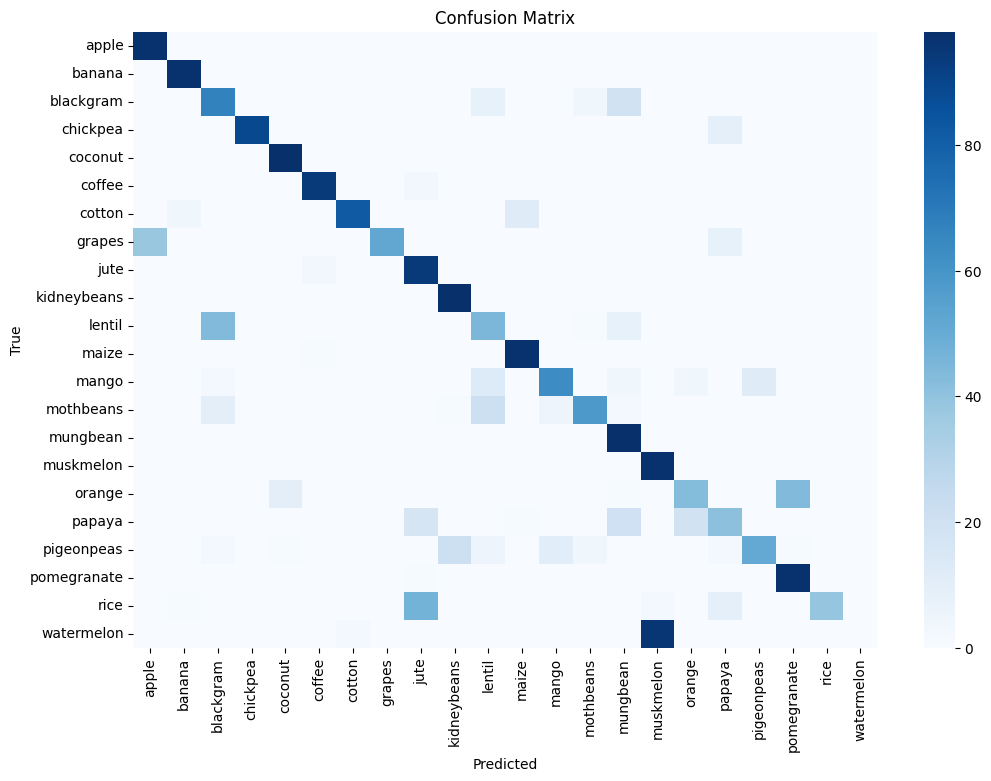

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()


This is for demo:(code to show prediction)

In [ ]:
# Example input: a new soil sample
sample = [[60, 46, 22, 24.89364635, 65.61418761, 6.625404347999999, 87.9298085]]  # N, P, K, temperature, humidity, pH, rainfall

# 1. Scale input with the same scaler used during training
sample_scaled = scaler.transform(sample)

# 2. Build kernel between this sample and training set
K_sample = quantum_kernel(sample_scaled, X_train)

# 3. Predict crop label
pred_label = qsvm.predict(K_sample)

# 4. Decode to original crop name
pred_crop = le.inverse_transform(pred_label)[0]

print("Predicted Crop:", pred_crop)


Predicted Crop: maize
